# How do structural descriptors see a melting crystal?

This notebook compares three primary discrete structure classifiers (adaptive CNA, interval CNA, and PTM), keeps fixed-cutoff CNA as a scale-sensitive diagnostic, and evaluates three Steinhardt neighborhood conventions for FCC and HCP trajectories. It analyzes at most `MAX_FRAMES = 100` frames per trajectory and only a subset of atoms is drawn in scatter plots.

It shows structure populations, per-atom classifier agreement, and standard, Lechner–Dellago averaged, and Voronoi-facet-weighted $q_4/q_6$ and normalized $\hat w_4/\hat w_6$ spaces.

> **Trajectory note.** The revised HCP trajectory now contains a late melting transition under the same gentle pressure-driven protocol and output cadence as FCC. The notebook infers dump timing automatically.

Run this with the `autoencode-statmech` conda environment; it contains OVITO, freud, pandas, scipy, and matplotlib.

In [64]:
from collections import OrderedDict
from pathlib import Path
import warnings
warnings.filterwarnings("ignore", message=".*OVITO.*PyPI")

import freud
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import numpy as np
import pandas as pd
from IPython.display import display
from ovito.io import import_file
from ovito.modifiers import CommonNeighborAnalysisModifier, PolyhedralTemplateMatchingModifier
from ovito.pipeline import Pipeline, StaticSource

plt.style.use("seaborn-v0_8-whitegrid")

def find_data_root():
    candidates = [Path.cwd(), Path.cwd() / "melting-crystals", Path.cwd().parent / "melting-crystals"]
    for candidate in candidates:
        if (candidate / "fcc/melting.lammpstrj").exists():
            return candidate.resolve()
    raise FileNotFoundError("Start the notebook in or directly above the melting-crystals directory.")

ROOT = find_data_root()
MAX_FRAMES = 100
RANDOM_REFERENCE_PARTICLES = 2500
LIQUID_CONSENSUS_THRESHOLD = 0.95
LIQUID_MSD_THRESHOLD = 0.5  # sigma^2
RNG = np.random.default_rng(17)

def estimate_random_q6(n_particles=RANDOM_REFERENCE_PARTICLES, seed=2718):
    rng = np.random.default_rng(seed)
    length = float(n_particles ** (1 / 3))
    box = freud.box.Box.cube(length)
    positions = rng.uniform(-length / 2, length / 2, size=(n_particles, 3)).astype(np.float32)
    q6 = freud.order.Steinhardt(l=6).compute((box, positions), neighbors={"num_neighbors": 12})
    return float(np.nanmean(q6.particle_order))

RANDOM_Q6_REFERENCE = estimate_random_q6()
RUNS = OrderedDict({
    "fcc": {"trajectory": ROOT / "fcc/melting.lammpstrj", "observables": ROOT / "fcc/melting_observables.dat",
            "observable_names": ["timestep", "temperature", "pressure", "potential", "volume", "density", "Q6"],
            "expected_id": 1, "first_step": 0, "dump_every": 1000},
    "hcp": {"trajectory": ROOT / "hcp/trajectory.lammpstrj", "observables": ROOT / "hcp/q6.dat",
            "observable_names": ["timestep", "Q6"], "expected_id": 2, "first_step": 10_000, "dump_every": 10_000},
})
print(f"Data root: {ROOT}\nHard analysis limit: {MAX_FRAMES} frames per run")

Data root: /home/jakob/Masterabeit/lammps-experiments/melting-crystals
Hard analysis limit: 100 frames per run


## 1. Select a few informative frames

If global $Q_6$ has a substantial dynamic range, the sampler places up to 100 frames asymmetrically around its steepest smoothed decrease: roughly two thirds before and one third after. Otherwise it uses evenly spaced coverage frames across the run. The dotted line is the mean $q_6$ of an ideal-gas reference with the same 12-nearest-neighbor definition. Only the selected trajectory frames are structurally analyzed.

,run,frame_index,estimated_timestep,sampling_strategy,robust_Q6_range
0,fcc,589,589000,"transition window (2/3 before, 1/3 after step ...",0.172503
1,fcc,595,595000,"transition window (2/3 before, 1/3 after step ...",0.172503
2,fcc,601,601000,"transition window (2/3 before, 1/3 after step ...",0.172503
3,fcc,607,607000,"transition window (2/3 before, 1/3 after step ...",0.172503
4,fcc,613,613000,"transition window (2/3 before, 1/3 after step ...",0.172503
...,...,...,...,...,...
195,hcp,1159,1159000,"transition window (2/3 before, 1/3 after step ...",0.106748
196,hcp,1165,1165000,"transition window (2/3 before, 1/3 after step ...",0.106748
197,hcp,1171,1171000,"transition window (2/3 before, 1/3 after step ...",0.106748
198,hcp,1177,1177000,"transition window (2/3 before, 1/3 after step ...",0.106748


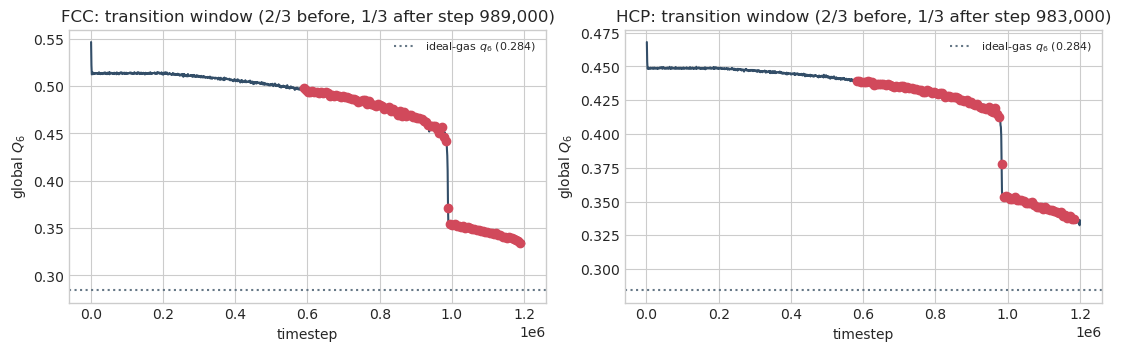

In [65]:
def read_observables(config):
    return pd.read_csv(config["observables"], comment="#", sep=r"\s+", names=config["observable_names"], engine="python")

def choose_frame_indices(observables, config, n_frames, max_frames=MAX_FRAMES):
    q6 = observables["Q6"].astype(float)
    robust_range = q6.quantile(0.95) - q6.quantile(0.05)
    transition_step = None
    if robust_range >= 0.08:
        smooth = q6.rolling(21, center=True, min_periods=3).median()
        center_step = int(observables.loc[smooth.diff().idxmin(), "timestep"])
        transition_step = center_step
        center = round((center_step - config["first_step"]) / config["dump_every"])
        frames_before = max(1, round(400_000 / config["dump_every"]))
        frames_after = max(1, round(200_000 / config["dump_every"]))
        first = max(0, center - frames_before)
        last = min(n_frames - 1, center + frames_after)
        indices = np.rint(np.linspace(first, last, min(max_frames, last - first + 1))).astype(int)
        strategy = f"transition window (2/3 before, 1/3 after step {center_step:,})"
    else:
        indices = np.rint(np.linspace(0, n_frames - 1, min(max_frames, n_frames))).astype(int)
        strategy = "even coverage (no resolved Q6 transition)"
    return np.unique(np.clip(indices, 0, n_frames - 1)), strategy, robust_range, transition_step

selection_rows = []
for run, config in RUNS.items():
    config["pipeline"] = import_file(str(config["trajectory"]), multiple_frames=True)
    config["first_step"] = int(config["pipeline"].compute(0).attributes["Timestep"])
    if config["pipeline"].num_frames > 1:
        second_step = int(config["pipeline"].compute(1).attributes["Timestep"])
        config["dump_every"] = second_step - config["first_step"]
    config["observables_df"] = read_observables(config)
    indices, strategy, q6_range, transition_step = choose_frame_indices(
        config["observables_df"], config, config["pipeline"].num_frames
    )
    config["frame_indices"], config["sampling_strategy"] = indices, strategy
    config["transition_step"] = transition_step
    for index in indices:
        selection_rows.append({"run": run, "frame_index": index,
            "estimated_timestep": config["first_step"] + index * config["dump_every"],
            "sampling_strategy": strategy, "robust_Q6_range": q6_range})
selection = pd.DataFrame(selection_rows)
display(selection)

fig, axes = plt.subplots(1, len(RUNS), figsize=(11, 3.4), constrained_layout=True)
for ax, (run, config) in zip(np.atleast_1d(axes), RUNS.items()):
    obs = config["observables_df"]
    picked = selection.loc[selection.run.eq(run), "estimated_timestep"]
    ax.plot(obs.timestep, obs.Q6, lw=1.5, color="#334e68")
    ax.scatter(picked, np.interp(picked, obs.timestep, obs.Q6), color="#d1495b", zorder=3)
    ax.axhline(RANDOM_Q6_REFERENCE, color="#657786", ls=":", lw=1.5,
               label=f"ideal-gas $q_6$ ({RANDOM_Q6_REFERENCE:.3f})")
    ax.set(title=f"{run.upper()}: {config['sampling_strategy']}", xlabel="timestep", ylabel="global $Q_6$")
    ax.ticklabel_format(axis="x", style="sci", scilimits=(0, 0))
    ax.legend(frameon=False, fontsize=8)
plt.show()

## 2. Dynamical sanity check: did each crystal melt?

Both trajectories now use the same gentle decompression protocol. Structural classifiers alone cannot prove melting, so we also check whether atoms lose memory of their lattice sites and acquire growing unwrapped displacement.

The periodic site MSD measures loss of the starting lattice positions; the incrementally unwrapped MSD measures continued motion across the periodic box. With only 100 sampled frames this remains a conservative diagnostic rather than a precision diffusion-coefficient estimate.

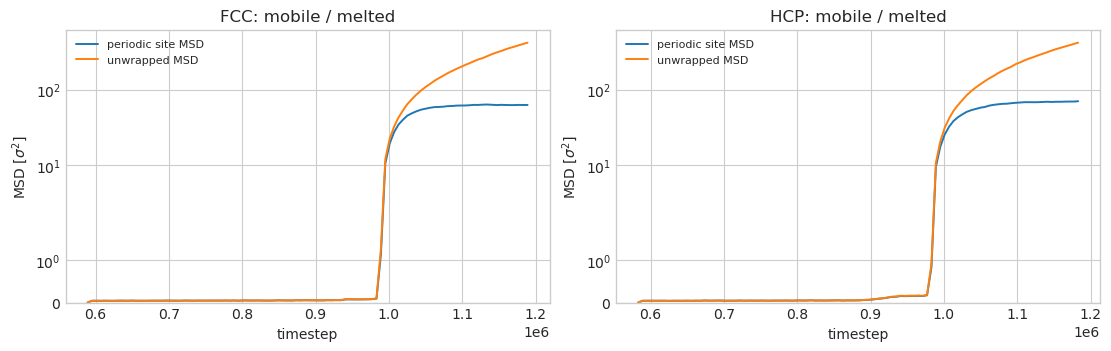

In [66]:
def displacement_diagnostics(config):
    reference = config["pipeline"].compute(int(config["frame_indices"][0]))
    reference_lengths = np.diag(np.asarray(reference.cell)[:, :3])
    reference_fractional = np.asarray(reference.particles.positions) / reference_lengths
    previous_fractional = reference_fractional.copy()
    unwrapped_displacement = np.zeros_like(np.asarray(reference.particles.positions), dtype=float)
    rows = []
    for frame_index in config["frame_indices"]:
        frame = config["pipeline"].compute(int(frame_index))
        current_lengths = np.diag(np.asarray(frame.cell)[:, :3])
        fractional = np.asarray(frame.particles.positions) / current_lengths
        site_delta = fractional - reference_fractional
        site_delta -= np.rint(site_delta)
        site_displacement = site_delta * reference_lengths
        site_displacement -= site_displacement.mean(axis=0)
        step_delta = fractional - previous_fractional
        step_delta -= np.rint(step_delta)
        step_displacement = step_delta * current_lengths
        step_displacement -= step_displacement.mean(axis=0)
        unwrapped_displacement += step_displacement
        previous_fractional = fractional
        rows.append({"timestep": int(frame.attributes["Timestep"]),
                     "site_MSD": np.mean(np.sum(site_displacement**2, axis=1)),
                     "unwrapped_MSD": np.mean(np.sum(unwrapped_displacement**2, axis=1))})
    return pd.DataFrame(rows)

dynamics = pd.concat([
    displacement_diagnostics(config).assign(run=run) for run, config in RUNS.items()
], ignore_index=True)

fig, axes = plt.subplots(1, len(RUNS), figsize=(11, 3.4), constrained_layout=True)
for ax, run in zip(np.atleast_1d(axes), RUNS):
    part = dynamics[dynamics.run.eq(run)]
    ax.plot(part.timestep, part.site_MSD, label="periodic site MSD", lw=1.4)
    ax.plot(part.timestep, part.unwrapped_MSD, label="unwrapped MSD", lw=1.4)
    melted = part.unwrapped_MSD.tail(10).median() > LIQUID_MSD_THRESHOLD
    ax.set(title=f"{run.upper()}: {'mobile / melted' if melted else 'caged'}", xlabel="timestep",
           ylabel=r"MSD [$\sigma^2$]", yscale="symlog", ylim=(-1e-3, None))
    ax.ticklabel_format(axis="x", style="sci", scilimits=(0, 0))
    ax.legend(frameon=False, fontsize=8)
plt.show()

## 3. Register and run the methods

Fixed CNA uses the FCC-oriented reduced-LJ cutoff 1.5; PTM uses RMSD cutoff 0.10. Cutoff 1.5 is too broad for the thermally smeared HCP neighbor shells, which is why fixed CNA calls that run almost entirely `other`; adaptive/interval CNA and PTM are the meaningful HCP comparisons. `Other` is not a perfect liquid label: it also includes defects and distorted crystal environments. Standard and Lechner–Dellago descriptors use 12 nearest neighbors; facet-weighted descriptors use Voronoi facet-area weights. The $w_l$ values are normalized third-order invariants.

In [67]:
STRUCTURE_NAMES = {0: "other / liquid-like", 1: "FCC", 2: "HCP", 3: "BCC", 4: "ICO",
                   5: "SC", 6: "cubic diamond", 7: "hexagonal diamond", 8: "graphene"}
STRUCTURE_COLORS = {"other / liquid-like": "#9aa5b1", "FCC": "#2878b5", "HCP": "#e07a1f",
                    "BCC": "#3a9d5d", "ICO": "#a05eb5", "SC": "#8c6d31",
                    "cubic diamond": "#d65f5f", "hexagonal diamond": "#6f63b6", "graphene": "#4f9d9d"}
CLASSIFIER_FACTORIES = OrderedDict({
    "CNA fixed (1.5; FCC-tuned)": lambda: CommonNeighborAnalysisModifier(mode=CommonNeighborAnalysisModifier.Mode.FixedCutoff, cutoff=1.5),
    "CNA adaptive": lambda: CommonNeighborAnalysisModifier(mode=CommonNeighborAnalysisModifier.Mode.AdaptiveCutoff),
    "CNA interval": lambda: CommonNeighborAnalysisModifier(mode=CommonNeighborAnalysisModifier.Mode.IntervalCutoff),
    "PTM (RMSD <= 0.10)": lambda: PolyhedralTemplateMatchingModifier(output_rmsd=True, rmsd_cutoff=0.10),
})
CORE_CLASSIFIERS = ["CNA adaptive", "CNA interval", "PTM (RMSD <= 0.10)"]
DIAGNOSTIC_CLASSIFIERS = ["CNA fixed (1.5; FCC-tuned)"]
DESCRIPTOR_STYLES = OrderedDict({
    "standard": {"average": False, "weighted": False},
    "Lechner-Dellago": {"average": True, "weighted": False},
    "Voronoi-facet": {"average": False, "weighted": True},
})

def classify_frame(raw_data):
    labels = {}
    for name, factory in CLASSIFIER_FACTORIES.items():
        pipeline = Pipeline(source=StaticSource(data=raw_data))
        pipeline.modifiers.append(factory())
        labels[name] = np.asarray(pipeline.compute().particles["Structure Type"], dtype=np.int8)
    return labels

def steinhardt_descriptors(raw_data):
    positions = np.asarray(raw_data.particles.positions)
    box = freud.box.Box.from_matrix(np.asarray(raw_data.cell)[:, :3])
    voronoi = freud.locality.Voronoi().compute((box, positions))
    output = {}
    for style, options in DESCRIPTOR_STYLES.items():
        neighbors = voronoi.nlist if options["weighted"] else {"num_neighbors": 12}
        suffix = style.lower().replace("-", "_")
        for prefix, wl in [("q", False), ("w", True)]:
            op = freud.order.Steinhardt(l=[4, 6], average=options["average"], weighted=options["weighted"],
                                        wl=wl, wl_normalize=wl)
            op.compute((box, positions), neighbors=neighbors)
            output[f"{prefix}4_{suffix}"] = op.particle_order[:, 0]
            output[f"{prefix}6_{suffix}"] = op.particle_order[:, 1]
    return output

In [68]:
particle_tables = []
for run, config in RUNS.items():
    for frame_index in config["frame_indices"]:
        raw = config["pipeline"].compute(int(frame_index))
        atom_ids = (np.asarray(raw.particles["Particle Identifier"], dtype=np.int32)
                    if "Particle Identifier" in raw.particles else np.arange(1, raw.particles.count + 1))
        positions = np.asarray(raw.particles.positions)
        frame = pd.DataFrame({"run": run, "frame_index": int(frame_index),
                              "timestep": int(raw.attributes["Timestep"]), "atom_id": atom_ids,
                              "x": positions[:, 0], "y": positions[:, 1], "z": positions[:, 2]})
        for name, values in classify_frame(raw).items():
            frame[name] = values
        for name, values in steinhardt_descriptors(raw).items():
            frame[name] = values
        particle_tables.append(frame)
    print(f"{run.upper()}: analyzed {len(config['frame_indices'])} frames")
particles = pd.concat(particle_tables, ignore_index=True)
print(f"\n{len(particles):,} atom-frames from {particles.groupby('run').frame_index.nunique().to_dict()} frames")

FCC: analyzed 100 frames
HCP: analyzed 100 frames

800,000 atom-frames from {'fcc': 100, 'hcp': 100} frames


## 4. Structure populations

Each panel is one classifier. The vertical axis is atom fraction and the horizontal axis is simulation timestep.

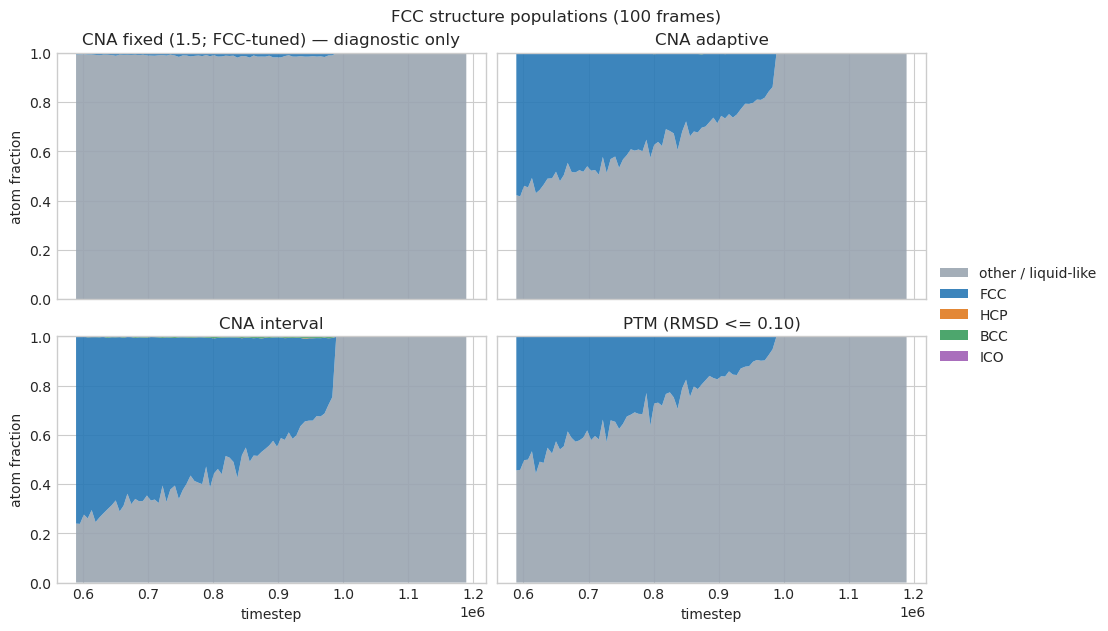

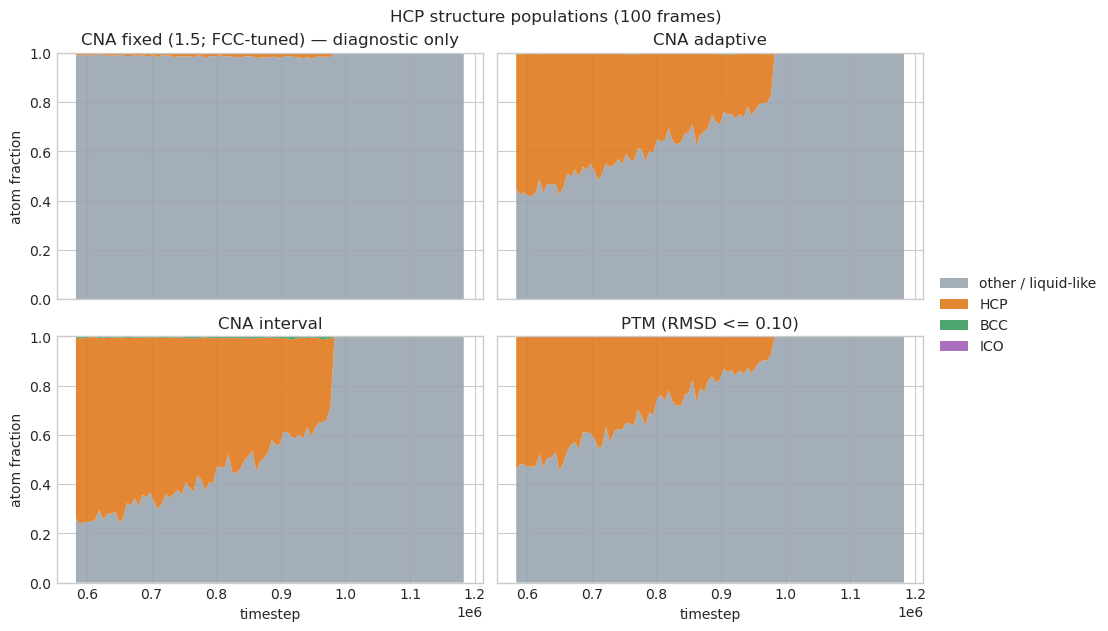

In [69]:
classifier_columns = list(CLASSIFIER_FACTORIES)
population_long = particles.melt(id_vars=["run", "frame_index", "timestep", "atom_id", "x", "y", "z"],
    value_vars=classifier_columns, var_name="method", value_name="structure_id")
population_long["structure"] = population_long.structure_id.map(STRUCTURE_NAMES).fillna("unknown")
fractions = population_long.groupby(["run", "timestep", "method", "structure"], observed=True).size().rename("count").reset_index()
fractions["fraction"] = fractions["count"] / fractions.groupby(["run", "timestep", "method"])["count"].transform("sum")

def plot_structure_fractions(run):
    fig, axes = plt.subplots(2, 2, figsize=(11, 6.2), sharex=True, sharey=True, constrained_layout=True)
    run_data = fractions[fractions.run.eq(run)]
    for ax, method in zip(axes.flat, classifier_columns):
        wide = run_data[run_data.method.eq(method)].pivot(index="timestep", columns="structure", values="fraction").fillna(0).sort_index()
        order = [name for name in STRUCTURE_COLORS if name in wide]
        ax.stackplot(wide.index, *[wide[name] for name in order], labels=order,
                     colors=[STRUCTURE_COLORS[name] for name in order], alpha=0.9)
        diagnostic = " — diagnostic only" if method in DIAGNOSTIC_CLASSIFIERS else ""
        ax.set_title(method + diagnostic); ax.set_ylim(0, 1); ax.ticklabel_format(axis="x", style="sci", scilimits=(0, 0))
    axes[0, 0].set_ylabel("atom fraction"); axes[1, 0].set_ylabel("atom fraction")
    axes[1, 0].set_xlabel("timestep"); axes[1, 1].set_xlabel("timestep")
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="outside right center", frameon=False)
    fig.suptitle(f"{run.upper()} structure populations ({len(RUNS[run]['frame_indices'])} frames)")
    plt.show()
for run in RUNS:
    plot_structure_fractions(run)

## 5. Agreement and an operational lower bound

The primary consensus uses **adaptive CNA, interval CNA, and PTM**. The **2-of-3 expected-crystal** curve is a majority-support summary; **3-of-3 Other** marks atoms for which every primary geometric method has lost a crystalline assignment. These are operational method-consensus summaries, not statistical confidence bounds or ground truth. Fixed-cutoff CNA remains visible as a diagnostic because its FCC-tuned absolute cutoff fails under density changes.

,run,timestep,core_expected_2_of_3,core_expected_unanimous,core_unanimous_other,core_any_2_of_3,all4_unanimous_other_diagnostic
0,fcc,589000,0.652,0.437,0.209,1.000,0.209
1,fcc,595000,0.658,0.435,0.209,0.999,0.209
2,fcc,601000,0.617,0.399,0.250,1.000,0.250
3,fcc,607000,0.622,0.394,0.232,1.000,0.232
4,fcc,613000,0.579,0.372,0.273,0.999,0.273
...,...,...,...,...,...,...,...
195,hcp,1159000,0.000,0.000,1.000,1.000,1.000
196,hcp,1165000,0.000,0.000,1.000,1.000,1.000
197,hcp,1171000,0.000,0.000,1.000,1.000,1.000
198,hcp,1177000,0.000,0.000,1.000,1.000,1.000


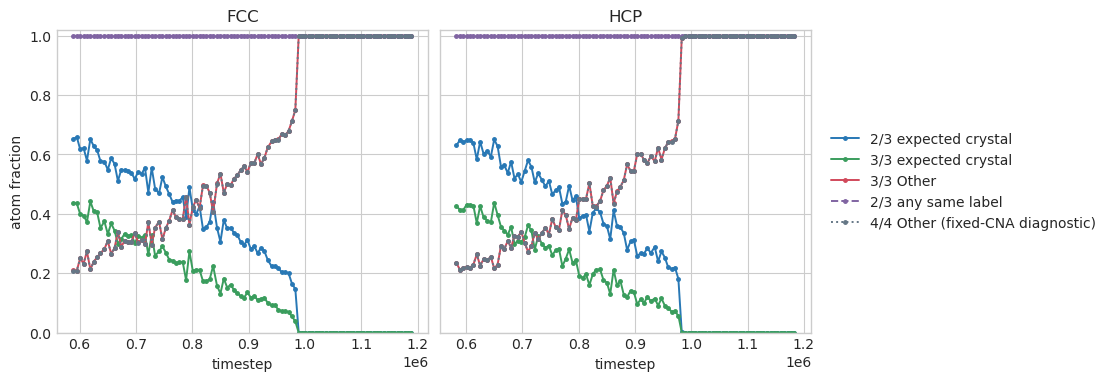

FCC pairwise disagreement (fixed-cutoff CNA is diagnostic only)


,CNA fixed (1.5; FCC-tuned),CNA adaptive,CNA interval,PTM (RMSD <= 0.10)
CNA fixed (1.5; FCC-tuned),0.000,0.248,0.358,0.198
CNA adaptive,0.248,0.000,0.114,0.143
CNA interval,0.358,0.114,0.000,0.192
PTM (RMSD <= 0.10),0.198,0.143,0.192,0.000


HCP pairwise disagreement (fixed-cutoff CNA is diagnostic only)


,CNA fixed (1.5; FCC-tuned),CNA adaptive,CNA interval,PTM (RMSD <= 0.10)
CNA fixed (1.5; FCC-tuned),0.000,0.258,0.368,0.210
CNA adaptive,0.258,0.000,0.115,0.146
CNA interval,0.368,0.115,0.000,0.194
PTM (RMSD <= 0.10),0.210,0.146,0.194,0.000


In [70]:
core_votes = particles[CORE_CLASSIFIERS].to_numpy(dtype=np.int8)
all_votes = particles[classifier_columns].to_numpy(dtype=np.int8)
expected_ids = particles.run.map({run: cfg["expected_id"] for run, cfg in RUNS.items()}).to_numpy()
particles["core_expected_votes"] = (core_votes == expected_ids[:, None]).sum(axis=1)
particles["core_max_same_label_votes"] = np.stack(
    [(core_votes == i).sum(axis=1) for i in STRUCTURE_NAMES], axis=1
).max(axis=1)
particles["core_expected_2_of_3"] = particles.core_expected_votes.ge(2)
particles["core_expected_unanimous"] = particles.core_expected_votes.eq(3)
particles["core_unanimous_other"] = (core_votes == 0).all(axis=1)
particles["core_any_2_of_3"] = particles.core_max_same_label_votes.ge(2)
particles["all4_unanimous_other_diagnostic"] = (all_votes == 0).all(axis=1)
agreement_columns = ["core_expected_2_of_3", "core_expected_unanimous",
                     "core_unanimous_other", "core_any_2_of_3",
                     "all4_unanimous_other_diagnostic"]
agreement = particles.groupby(["run", "timestep"])[agreement_columns].mean().reset_index()
display(agreement.round(3))

fig, axes = plt.subplots(1, len(RUNS), figsize=(11, 3.7), sharey=True, constrained_layout=True)
curve_styles = {
    "core_expected_2_of_3": ("2/3 expected crystal", "#2878b5", "-"),
    "core_expected_unanimous": ("3/3 expected crystal", "#3a9d5d", "-"),
    "core_unanimous_other": ("3/3 Other", "#d1495b", "-"),
    "core_any_2_of_3": ("2/3 any same label", "#8064a2", "--"),
    "all4_unanimous_other_diagnostic": ("4/4 Other (fixed-CNA diagnostic)", "#657786", ":"),
}
for ax, run in zip(np.atleast_1d(axes), RUNS):
    part = agreement[agreement.run.eq(run)]
    for column, (label, color, linestyle) in curve_styles.items():
        ax.plot(part.timestep, part[column], marker="o", ms=2.5, lw=1.4,
                color=color, ls=linestyle, label=label)
    ax.set(title=run.upper(), xlabel="timestep", ylim=(0, 1.02)); ax.ticklabel_format(axis="x", style="sci", scilimits=(0, 0))
axes[0].set_ylabel("atom fraction"); axes[-1].legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
plt.show()

def pairwise_disagreement(run):
    subset = particles[particles.run.eq(run)]
    return pd.DataFrame([[(subset[a] != subset[b]).mean() for b in classifier_columns] for a in classifier_columns],
                        index=classifier_columns, columns=classifier_columns)
for run in RUNS:
    print(f"{run.upper()} pairwise disagreement (fixed-cutoff CNA is diagnostic only)")
    display(pairwise_disagreement(run).round(3))

## 6. Select an empirical dense-liquid reference

A sampled frame enters the empirical liquid reference only when it is after the detected $Q_6$ decline, at least 95% of its atoms are unanimously `Other` according to the three primary classifiers, and its unwrapped MSD exceeds $0.5\,\sigma^2$. This deliberately conservative intersection combines structural-method failure with actual particle mobility. It is still an **operational reference**, not externally labelled ground truth.

Selection thresholds: unanimous Other >= 95%, unwrapped MSD >= 0.50 sigma^2


,reference_frames,first_step,last_step,mean_core_unanimous_other,minimum_unwrapped_MSD
run,,,,,
fcc,34,989000,1189000,1.0,1.281
hcp,34,983000,1183000,1.0,0.928


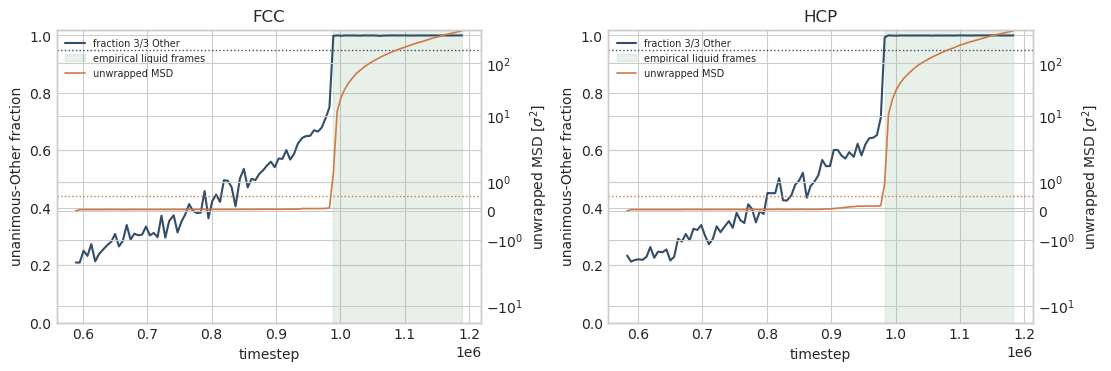

In [71]:
frame_diagnostics = agreement[["run", "timestep", "core_unanimous_other"]].merge(
    dynamics, on=["run", "timestep"], how="inner"
)
diagnostic_parts = []
for run, part in frame_diagnostics.groupby("run", sort=False):
    transition_step = RUNS[run].get("transition_step")
    late_cutoff = transition_step if transition_step is not None else part.timestep.quantile(2 / 3)
    diagnostic_parts.append(part.assign(transition_step=late_cutoff, after_decline=part.timestep.ge(late_cutoff)))
frame_diagnostics = pd.concat(diagnostic_parts, ignore_index=True)
frame_diagnostics["liquid_reference_frame"] = (
    frame_diagnostics.after_decline
    & frame_diagnostics.core_unanimous_other.ge(LIQUID_CONSENSUS_THRESHOLD)
    & frame_diagnostics.unwrapped_MSD.ge(LIQUID_MSD_THRESHOLD)
)
liquid_frames = frame_diagnostics[frame_diagnostics.liquid_reference_frame].copy()
liquid_keys = liquid_frames[["run", "timestep"]]
empirical_liquid = particles.merge(liquid_keys, on=["run", "timestep"], how="inner")

print(f"Selection thresholds: unanimous Other >= {LIQUID_CONSENSUS_THRESHOLD:.0%}, "
      f"unwrapped MSD >= {LIQUID_MSD_THRESHOLD:.2f} sigma^2")
if liquid_frames.empty:
    print("No frame passes the conservative liquid-reference criteria. Inspect the diagnostic curves.")
else:
    reference_summary = liquid_frames.groupby("run").agg(
        reference_frames=("timestep", "size"), first_step=("timestep", "min"),
        last_step=("timestep", "max"), mean_core_unanimous_other=("core_unanimous_other", "mean"),
        minimum_unwrapped_MSD=("unwrapped_MSD", "min"),
    )
    display(reference_summary.round(3))

fig, axes = plt.subplots(1, len(RUNS), figsize=(11, 3.6), constrained_layout=True)
for ax, run in zip(np.atleast_1d(axes), RUNS):
    part = frame_diagnostics[frame_diagnostics.run.eq(run)].sort_values("timestep")
    chosen = part[part.liquid_reference_frame]
    ax.plot(part.timestep, part.core_unanimous_other, color="#334e68", lw=1.5, label="fraction 3/3 Other")
    ax.axhline(LIQUID_CONSENSUS_THRESHOLD, color="#334e68", ls=":", lw=1)
    if not chosen.empty:
        ax.axvspan(chosen.timestep.min(), chosen.timestep.max(), color="#70a37f", alpha=0.16,
                   label="empirical liquid frames")
    mobility_ax = ax.twinx()
    mobility_ax.plot(part.timestep, part.unwrapped_MSD, color="#d17a45", lw=1.2,
                     label="unwrapped MSD")
    mobility_ax.axhline(LIQUID_MSD_THRESHOLD, color="#d17a45", ls=":", lw=1)
    mobility_ax.set_yscale("symlog")
    ax.set(title=run.upper(), xlabel="timestep", ylabel="unanimous-Other fraction", ylim=(0, 1.02))
    mobility_ax.set_ylabel(r"unwrapped MSD [$\sigma^2$]")
    ax.ticklabel_format(axis="x", style="sci", scilimits=(0, 0))
    handles1, labels1 = ax.get_legend_handles_labels(); handles2, labels2 = mobility_ax.get_legend_handles_labels()
    ax.legend(handles1 + handles2, labels1 + labels2, loc="upper left", frameon=False, fontsize=7)
plt.show()

## 7. Steinhardt 4/6 spaces and reference distributions

These panels summarize how the **whole per-atom descriptor distribution moves**, rather than drawing individual neighborhoods. The connected colored points are the distribution centroid for every sampled frame; color encodes timestep and the outlined ellipses show the central 68% spread at five representative frames. The star is the analytically generated perfect starting crystal. Gray marks the periodic ideal gas; amber marks the empirical dense liquid selected above. Both references show a soft 50% core inside their broader 95% ellipse.

In [72]:
def descriptor_reference(n_particles=RANDOM_REFERENCE_PARTICLES):
    length = float(n_particles ** (1 / 3)); box = freud.box.Box.cube(length)
    positions = RNG.uniform(-length / 2, length / 2, size=(n_particles, 3)).astype(np.float32)
    voronoi = freud.locality.Voronoi().compute((box, positions)); output = {}
    for style, options in DESCRIPTOR_STYLES.items():
        neighbors = voronoi.nlist if options["weighted"] else {"num_neighbors": 12}
        suffix = style.lower().replace("-", "_")
        for prefix, wl in [("q", False), ("w", True)]:
            op = freud.order.Steinhardt(l=[4, 6], average=options["average"], weighted=options["weighted"], wl=wl, wl_normalize=wl)
            op.compute((box, positions), neighbors=neighbors)
            output[f"{prefix}4_{suffix}"] = op.particle_order[:, 0]
            output[f"{prefix}6_{suffix}"] = op.particle_order[:, 1]
    return pd.DataFrame(output)

def perfect_crystal_system(run, n_cells=6, density=1.2):
    if run == "fcc":
        a = (4 / density) ** (1 / 3)
        cell_lengths = np.array([a, a, a])
        basis = np.array([[0, 0, 0], [.5, .5, 0], [.5, 0, .5], [0, .5, .5]])
    elif run == "hcp":
        a = (np.sqrt(2) / density) ** (1 / 3)
        cell_lengths = np.array([a, np.sqrt(3) * a, np.sqrt(8 / 3) * a])
        basis = np.array([[0, 0, 0], [.5, .5, 0], [.5, 5 / 6, .5], [0, 1 / 3, .5]])
    else:
        raise ValueError(f"Unknown crystal: {run}")
    positions = np.concatenate([
        (np.array([i, j, k]) + basis) * cell_lengths
        for i in range(n_cells) for j in range(n_cells) for k in range(n_cells)
    ]).astype(np.float32)
    box_lengths = n_cells * cell_lengths
    return freud.box.Box(*box_lengths), positions

def perfect_crystal_references():
    rows = []
    for run in RUNS:
        box, positions = perfect_crystal_system(run)
        voronoi = freud.locality.Voronoi().compute((box, positions))
        row = {"run": run}
        for style, options in DESCRIPTOR_STYLES.items():
            neighbors = voronoi.nlist if options["weighted"] else {"num_neighbors": 12}
            suffix = style.lower().replace("-", "_")
            for prefix, wl in [("q", False), ("w", True)]:
                op = freud.order.Steinhardt(l=[4, 6], average=options["average"], weighted=options["weighted"],
                                            wl=wl, wl_normalize=wl)
                op.compute((box, positions), neighbors=neighbors)
                row[f"{prefix}4_{suffix}"] = float(np.nanmean(op.particle_order[:, 0]))
                row[f"{prefix}6_{suffix}"] = float(np.nanmean(op.particle_order[:, 1]))
        rows.append(row)
    return pd.DataFrame(rows).set_index("run")

random_reference = descriptor_reference()
perfect_reference = perfect_crystal_references()
display(random_reference.describe().loc[["mean", "std"]].round(4))
display(perfect_reference.round(4))

Order 4 vertex memory scaled up to 16


,q4_standard,q6_standard,w4_standard,w6_standard,q4_lechner_dellago,q6_lechner_dellago,w4_lechner_dellago,w6_lechner_dellago,q4_voronoi_facet,q6_voronoi_facet,w4_voronoi_facet,w6_voronoi_facet
mean,0.2841,0.2853,0.0234,-0.0183,0.0965,0.0977,0.0211,0.0019,0.3500,0.3532,0.0403,-0.0313
std,0.0652,0.0552,0.0677,0.0411,0.0258,0.0210,0.0667,0.0407,0.0804,0.0736,0.0652,0.0390


,q4_standard,q6_standard,w4_standard,w6_standard,q4_lechner_dellago,q6_lechner_dellago,w4_lechner_dellago,w6_lechner_dellago,q4_voronoi_facet,q6_voronoi_facet,w4_voronoi_facet,w6_voronoi_facet
run,,,,,,,,,,,,
fcc,0.1909,0.5745,-0.1593,-0.0132,0.1909,0.5745,-0.1593,-0.0132,0.1909,0.5745,-0.1593,-0.0132
hcp,0.0972,0.4848,0.1341,-0.0124,0.0972,0.4848,0.1341,-0.0124,0.0972,0.4848,0.1341,-0.0124


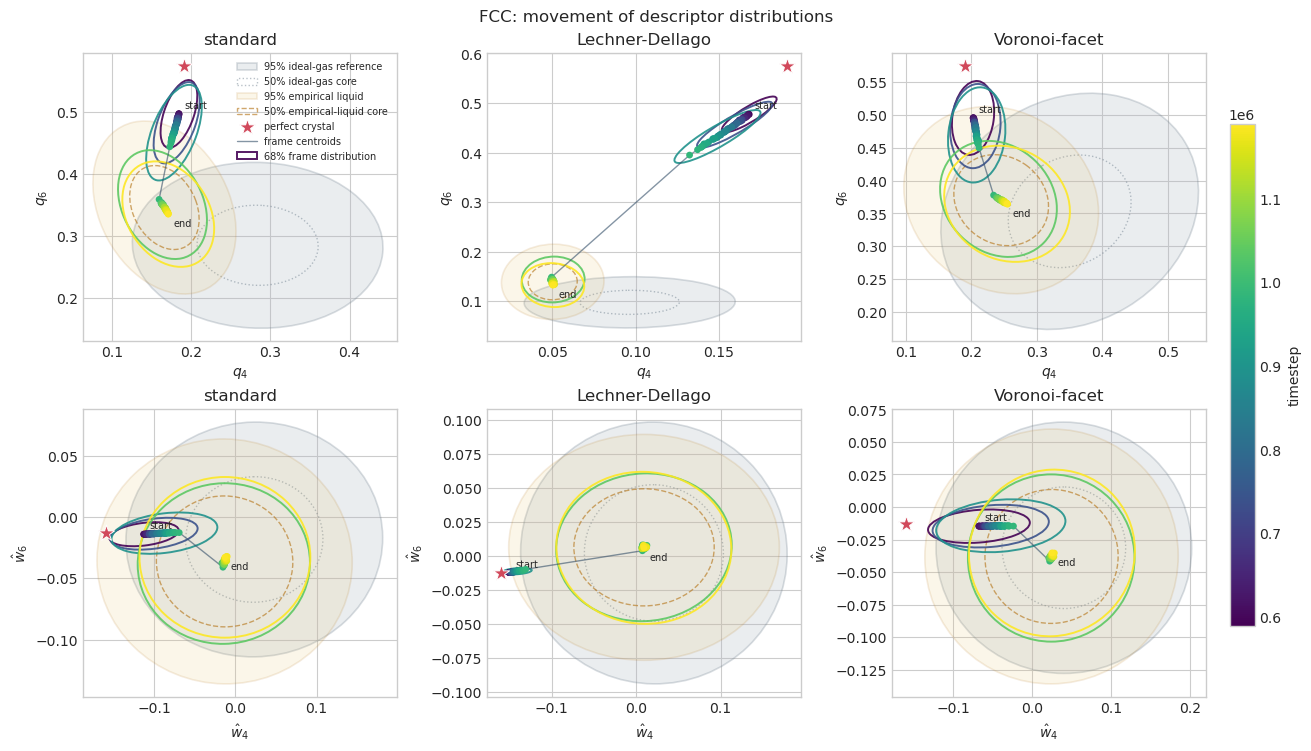

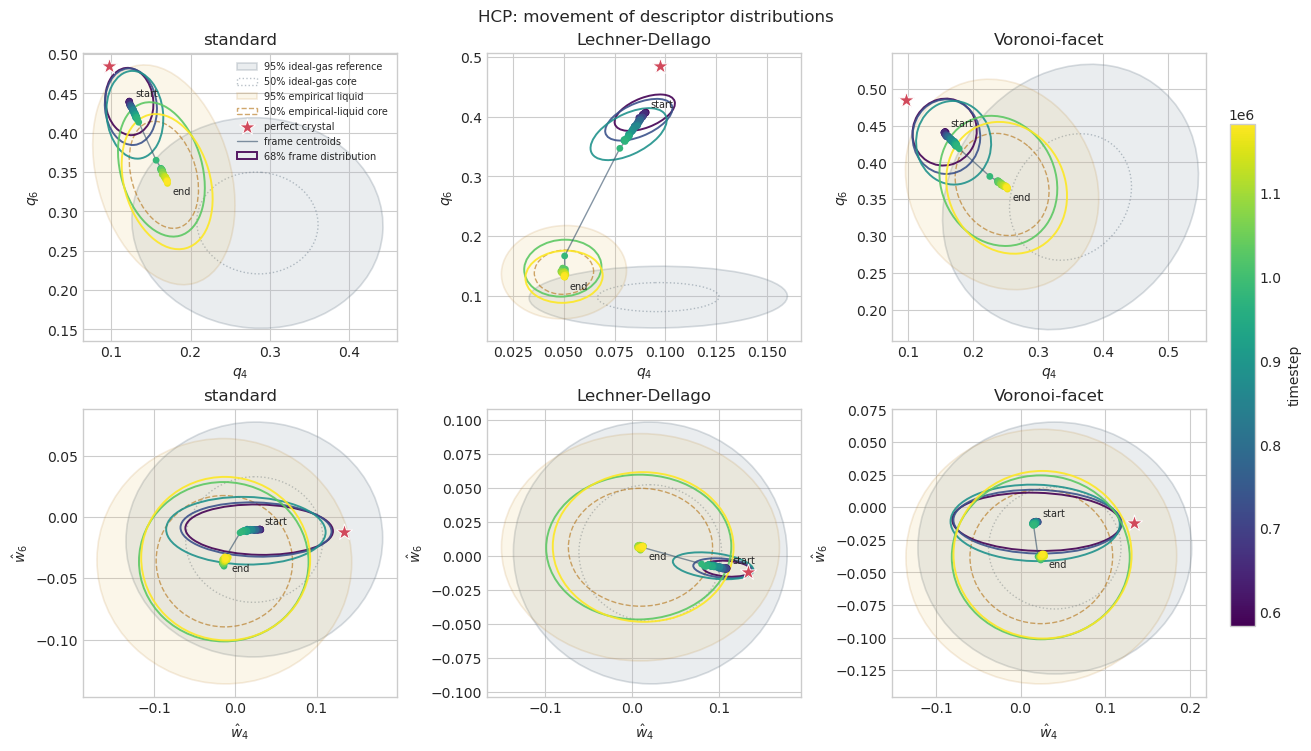

In [73]:
def add_distribution_ellipse(ax, x, y, coverage, *, facecolor, edgecolor, alpha, label=None, lw=1.2, linestyle="-"):
    points = np.column_stack([x, y]); points = points[np.isfinite(points).all(axis=1)]
    if len(points) < 3:
        return
    center = points.mean(axis=0); covariance = np.cov(points, rowvar=False)
    inverse = np.linalg.pinv(covariance)
    d2 = np.einsum("ni,ij,nj->n", points - center, inverse, points - center)
    eigenvalues, eigenvectors = np.linalg.eigh(covariance); order = eigenvalues.argsort()[::-1]
    eigenvalues, eigenvectors = eigenvalues[order], eigenvectors[:, order]
    angle = np.degrees(np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0]))
    width, height = 2 * np.sqrt(np.maximum(eigenvalues, 0) * np.quantile(d2, coverage))
    ax.add_patch(Ellipse(center, width, height, angle=angle, facecolor=facecolor, edgecolor=edgecolor,
                         alpha=alpha, lw=lw, linestyle=linestyle, label=label))

def plot_descriptor_spaces(run):
    run_data = particles[particles.run.eq(run)]
    steps = np.sort(run_data.timestep.unique())
    ellipse_steps = np.unique(steps[np.rint(np.linspace(0, len(steps) - 1, 5)).astype(int)])
    norm = plt.Normalize(steps.min(), steps.max()); cmap = plt.cm.viridis
    fig, axes = plt.subplots(2, 3, figsize=(13, 7.4), constrained_layout=True)
    mappable = None

    for column, (style, _) in enumerate(DESCRIPTOR_STYLES.items()):
        suffix = style.lower().replace("-", "_")
        for row, prefix in enumerate(["q", "w"]):
            ax = axes[row, column]; xcol, ycol = f"{prefix}4_{suffix}", f"{prefix}6_{suffix}"
            add_distribution_ellipse(ax, random_reference[xcol], random_reference[ycol], 0.95,
                                     facecolor="#aeb8c2", edgecolor="#657786", alpha=0.25,
                                     label="95% ideal-gas reference")
            add_distribution_ellipse(ax, random_reference[xcol], random_reference[ycol], 0.50,
                                     facecolor="none", edgecolor="#657786", alpha=0.45, lw=1.0,
                                     linestyle=":", label="50% ideal-gas core")
            dense_liquid = empirical_liquid[empirical_liquid.run.eq(run)]
            if not dense_liquid.empty:
                add_distribution_ellipse(ax, dense_liquid[xcol], dense_liquid[ycol], 0.95,
                                         facecolor="#e9c46a", edgecolor="#b7791f", alpha=0.14,
                                         label="95% empirical liquid")
                add_distribution_ellipse(ax, dense_liquid[xcol], dense_liquid[ycol], 0.50,
                                         facecolor="none", edgecolor="#b7791f", alpha=0.65, lw=1.0,
                                         linestyle="--", label="50% empirical-liquid core")
            perfect = perfect_reference.loc[run]
            ax.scatter(perfect[xcol], perfect[ycol], marker="*", s=150, color="#d1495b",
                       edgecolor="white", linewidth=.7, zorder=6, label="perfect crystal")

            centroids = run_data.groupby("timestep")[[xcol, ycol]].mean().sort_index()
            ax.plot(centroids[xcol], centroids[ycol], color="#334e68", lw=1.0, alpha=0.6,
                    label="frame centroids")
            mappable = ax.scatter(centroids[xcol], centroids[ycol], c=centroids.index, cmap=cmap, norm=norm,
                                  s=24, edgecolor="none", zorder=4)

            for ellipse_index, step in enumerate(ellipse_steps):
                cloud = run_data[run_data.timestep.eq(step)]
                add_distribution_ellipse(ax, cloud[xcol], cloud[ycol], 0.68, facecolor="none",
                                         edgecolor=cmap(norm(step)), alpha=0.9, lw=1.4,
                                         label="68% frame distribution" if ellipse_index == 0 else None)
            ax.annotate("start", (centroids.iloc[0][xcol], centroids.iloc[0][ycol]),
                        xytext=(4, 4), textcoords="offset points", fontsize=7)
            ax.annotate("end", (centroids.iloc[-1][xcol], centroids.iloc[-1][ycol]),
                        xytext=(4, -9), textcoords="offset points", fontsize=7)
            symbol = "q" if prefix == "q" else r"\hat w"
            ax.set(xlabel=fr"${symbol}_4$", ylabel=fr"${symbol}_6$", title=style)

    fig.colorbar(mappable, ax=axes, label="timestep", shrink=0.78, pad=0.02)
    axes[0, 0].legend(loc="best", fontsize=7, frameon=False)
    fig.suptitle(f"{run.upper()}: movement of descriptor distributions")
    plt.show()

for run in RUNS:
    plot_descriptor_spaces(run)

## 8. When the geometric classifiers fail, is q-space already liquid-like?

A classifier two-sample test (C2ST) compares a five-frame window around each state with five late empirical-liquid frames from the **other** run. Cross-validation holds out complete frames rather than random atoms. Thus an AUC near 0.5 means that the chosen descriptor set cannot reliably separate that state from an independent liquid reference; it does not prove equality of the underlying distributions. The interval is a bootstrap over held-out-frame folds. Four feature sets test whether averaging or the normalized third-order invariants retain information that standard $q_4/q_6$ misses.

FCC: frame-held-out C2ST complete for 100 states
HCP: frame-held-out C2ST complete for 100 states


minimum_AUC  final_AUC
run feature_set                        
fcc all q              0.397      0.565
    averaged q         0.395      0.567
    q + w              0.408      0.551
    standard q         0.444      0.544
hcp all q              0.483      0.560
    averaged q         0.473      0.551
    q + w              0.482      0.548
    standard q         0.470      0.548

,run,timestep,offset_from_Q6_decline,auc,auc_low,auc_high
0,fcc,965000,-24000,1.000,1.000,1.000
1,fcc,977000,-12000,0.875,0.625,1.000
2,fcc,983000,-6000,0.778,0.526,1.000
3,fcc,989000,0,0.724,0.529,0.917
4,fcc,995000,6000,0.395,0.186,0.547
5,fcc,1001000,12000,0.496,0.421,0.554
6,fcc,1013000,24000,0.450,0.378,0.505
7,fcc,1037000,48000,0.449,0.401,0.500
8,hcp,959000,-24000,1.000,1.000,1.000
9,hcp,971000,-12000,0.921,0.763,1.000


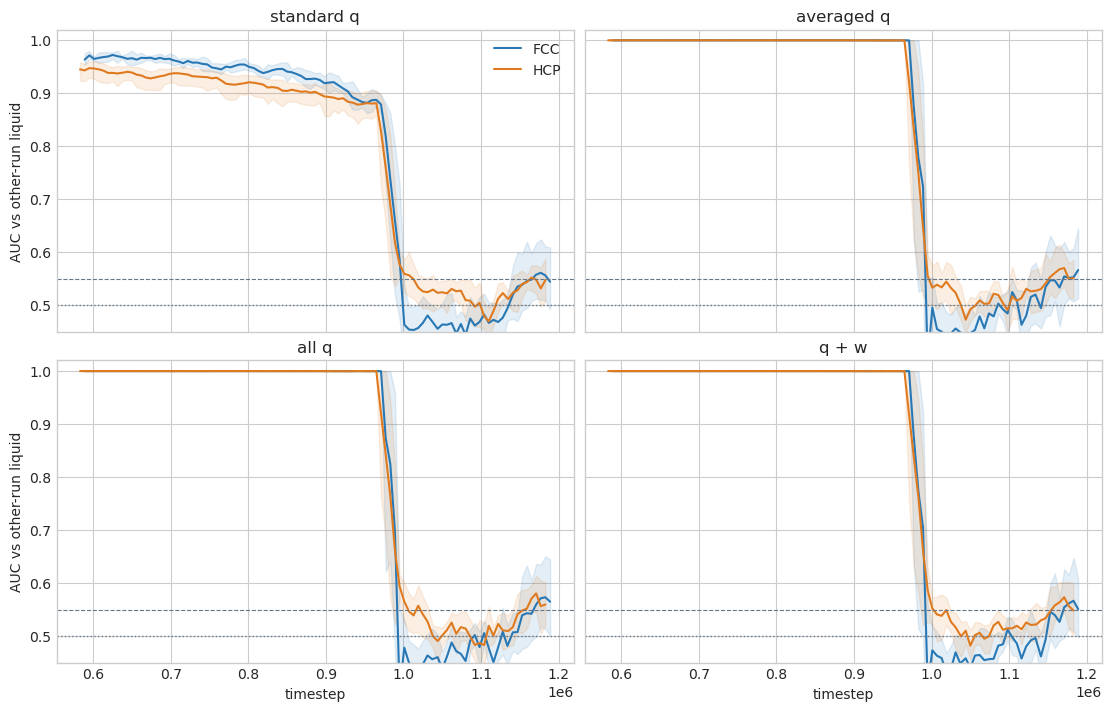

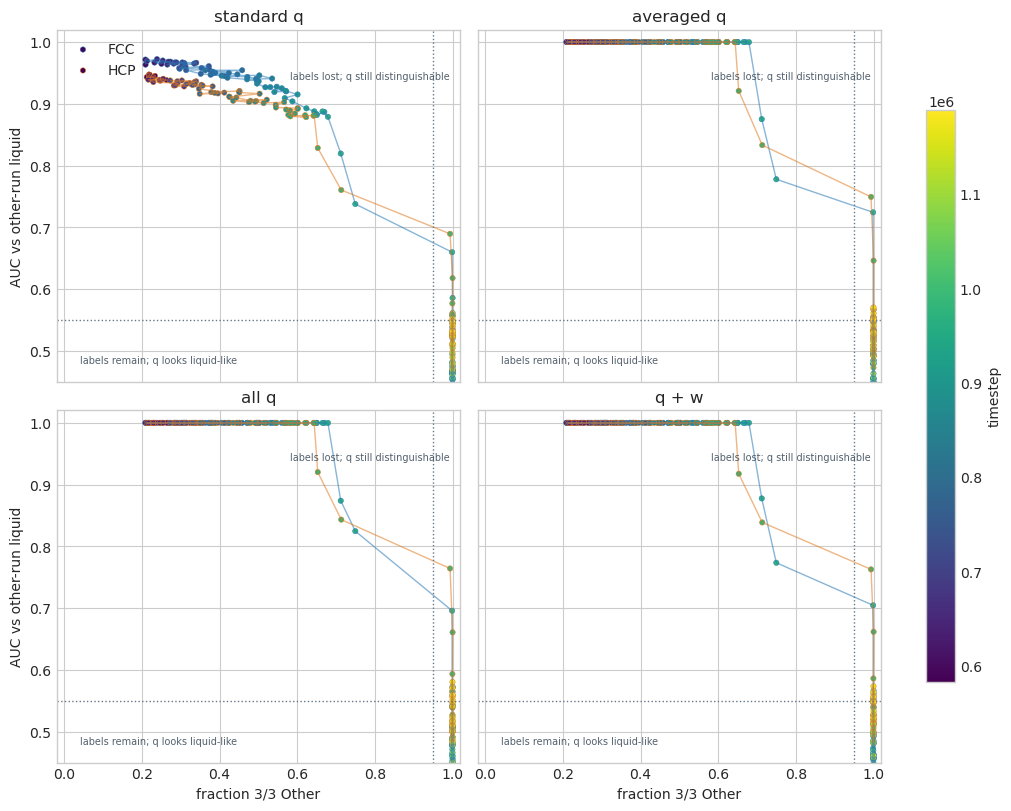

In [74]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

C2ST_ATOMS_PER_FRAME = 200
C2ST_WINDOW_FRAMES = 5
C2ST_BOOTSTRAPS = 500
C2ST_FEATURES = OrderedDict({
    "standard q": ["q4_standard", "q6_standard"],
    "averaged q": ["q4_lechner_dellago", "q6_lechner_dellago"],
    "all q": [f"q{l}_{suffix}" for suffix in ["standard", "lechner_dellago", "voronoi_facet"] for l in [4, 6]],
    "q + w": [f"{prefix}{l}_{suffix}" for suffix in ["standard", "lechner_dellago", "voronoi_facet"]
              for prefix in ["q", "w"] for l in [4, 6]],
})
ALL_C2ST_COLUMNS = list(dict.fromkeys(column for columns in C2ST_FEATURES.values() for column in columns))

def evenly_spaced(values, count):
    values = np.sort(np.unique(values))
    return values[np.unique(np.rint(np.linspace(0, len(values) - 1, min(count, len(values)))).astype(int))]

def sample_complete_frames(table, steps, seed):
    pieces = []
    for offset, step in enumerate(steps):
        frame = table[table.timestep.eq(step)]
        pieces.append(frame.sample(n=min(C2ST_ATOMS_PER_FRAME, len(frame)), random_state=seed + offset))
    return pd.concat(pieces, ignore_index=True)

def c2st_with_frame_holdout(dataset, columns, seed):
    finite = dataset[columns].notna().all(axis=1)
    data = dataset.loc[finite]
    X = data[columns].to_numpy(); y = data["is_target"].to_numpy(dtype=np.int8)
    groups = (data.run.astype(str) + ":" + data.timestep.astype(str)).to_numpy()
    n_splits = min(5, data.loc[data.is_target.eq(1), "timestep"].nunique(),
                   data.loc[data.is_target.eq(0), "timestep"].nunique())
    splitter = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    fold_aucs = []
    for train, test in splitter.split(X, y, groups):
        model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=300, C=1.0))
        model.fit(X[train], y[train])
        fold_aucs.append(roc_auc_score(y[test], model.predict_proba(X[test])[:, 1]))
    fold_aucs = np.asarray(fold_aucs)
    rng = np.random.default_rng(seed + 10_000)
    boot = rng.choice(fold_aucs, size=(C2ST_BOOTSTRAPS, len(fold_aucs)), replace=True).mean(axis=1)
    return fold_aucs.mean(), *np.quantile(boot, [0.025, 0.975])

liquid_samples = {}
for run in RUNS:
    reference_steps = evenly_spaced(empirical_liquid.loc[empirical_liquid.run.eq(run), "timestep"], C2ST_WINDOW_FRAMES)
    liquid_samples[run] = sample_complete_frames(empirical_liquid[empirical_liquid.run.eq(run)], reference_steps, 3000)

separability_rows = []
for run_index, run in enumerate(RUNS):
    opposite_run = next(other for other in RUNS if other != run)
    run_data = particles[particles.run.eq(run)]
    steps = np.sort(run_data.timestep.unique())
    for step_index, step in enumerate(steps):
        start = np.clip(step_index - C2ST_WINDOW_FRAMES // 2, 0, max(0, len(steps) - C2ST_WINDOW_FRAMES))
        local_steps = steps[start:start + C2ST_WINDOW_FRAMES]
        target = sample_complete_frames(run_data, local_steps, 1000 + 100 * run_index + step_index).assign(is_target=1)
        reference = liquid_samples[opposite_run].assign(is_target=0)
        dataset = pd.concat([target, reference], ignore_index=True)
        for feature_index, (feature_set, columns) in enumerate(C2ST_FEATURES.items()):
            auc, low, high = c2st_with_frame_holdout(dataset, columns, 7000 + 100 * step_index + feature_index)
            separability_rows.append({"run": run, "timestep": step, "feature_set": feature_set,
                                       "auc": auc, "auc_low": low, "auc_high": high,
                                       "liquid_reference_run": opposite_run})
    print(f"{run.upper()}: frame-held-out C2ST complete for {len(steps)} states")
q_separability = pd.DataFrame(separability_rows)
display(q_separability.groupby(["run", "feature_set"]).agg(
    minimum_AUC=("auc", "min"), final_AUC=("auc", "last")
).round(3))
event_rows = []
for run in RUNS:
    center = RUNS[run]["transition_step"]
    part = q_separability[q_separability.run.eq(run) & q_separability.feature_set.eq("averaged q")]
    for offset in [-24_000, -12_000, -6_000, 0, 6_000, 12_000, 24_000, 48_000]:
        nearest = part.iloc[np.abs(part.timestep.to_numpy() - (center + offset)).argmin()]
        event_rows.append(nearest.to_dict() | {"offset_from_Q6_decline": offset})
event_q_summary = pd.DataFrame(event_rows).drop_duplicates(["run", "timestep"])
display(event_q_summary[["run", "timestep", "offset_from_Q6_decline", "auc", "auc_low", "auc_high"]].round(3))

fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True, sharey=True, constrained_layout=True)
run_colors = {"fcc": "#2878b5", "hcp": "#e07a1f"}
for ax, feature_set in zip(axes.flat, C2ST_FEATURES):
    for run in RUNS:
        part = q_separability[q_separability.run.eq(run) & q_separability.feature_set.eq(feature_set)].sort_values("timestep")
        ax.fill_between(part.timestep, part.auc_low, part.auc_high, color=run_colors[run], alpha=0.12)
        ax.plot(part.timestep, part.auc, color=run_colors[run], lw=1.5, label=run.upper())
    ax.axhline(0.50, color="#657786", ls=":", lw=1); ax.axhline(0.55, color="#657786", ls="--", lw=.8)
    ax.set(title=feature_set, ylim=(0.45, 1.02)); ax.ticklabel_format(axis="x", style="sci", scilimits=(0, 0))
for ax in axes[-1]: ax.set_xlabel("timestep")
for ax in axes[:, 0]: ax.set_ylabel("AUC vs other-run liquid")
axes[0, 0].legend(frameon=False); plt.show()

failure_map = q_separability.merge(agreement[["run", "timestep", "core_unanimous_other"]],
                                   on=["run", "timestep"], how="left")
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True, constrained_layout=True)
failure_norm = plt.Normalize(failure_map.timestep.min(), failure_map.timestep.max())
failure_mappable = None
for ax, feature_set in zip(axes.flat, C2ST_FEATURES):
    for run in RUNS:
        part = failure_map[failure_map.run.eq(run) & failure_map.feature_set.eq(feature_set)].sort_values("timestep")
        ax.plot(part.core_unanimous_other, part.auc, color=run_colors[run], alpha=.55, lw=1)
        failure_mappable = ax.scatter(part.core_unanimous_other, part.auc, c=part.timestep, cmap="viridis", norm=failure_norm, s=15,
                   edgecolor=run_colors[run], linewidth=.35, label=run.upper())
    ax.axvline(LIQUID_CONSENSUS_THRESHOLD, color="#657786", ls=":", lw=1)
    ax.axhline(0.55, color="#657786", ls=":", lw=1)
    ax.set(title=feature_set, xlim=(-.02, 1.02), ylim=(.45, 1.02))
    ax.text(.04, .48, "labels remain; q looks liquid-like", fontsize=7, color="#52606d")
    ax.text(.58, .94, "labels lost; q still distinguishable", fontsize=7, color="#52606d")
for ax in axes[-1]: ax.set_xlabel("fraction 3/3 Other")
for ax in axes[:, 0]: ax.set_ylabel("AUC vs other-run liquid")
axes[0, 0].legend(frameon=False); fig.colorbar(failure_mappable, ax=axes, label="timestep", shrink=.78); plt.show()


## 9. Inspect near-liquid mismatch frames

This block deliberately inspects the last state in each run where at least half (but not yet 95%) of atoms are `Other` under all three primary methods while averaged q-space remains distinguishable from the opposite-run liquid (bootstrap lower bound above 0.55). In q-space, highlighted atoms are both unanimously `Other` and outside the other-run liquid's empirical 95% Mahalanobis contour. The spatial projection asks whether this residual signal forms an interface/domain or is dispersed noise. Change `INSPECTION_STEPS` to override the automatic choices.

,run,timestep,core_unanimous_other,auc,auc_low,auc_high
0,fcc,977000,0.712,0.875,0.625,1.0
1,hcp,977000,0.713,0.833,0.623,1.0


,run,timestep,fraction_3_of_3_other,fraction_residual_q_signal
0,fcc,977000,0.712,0.712
1,hcp,977000,0.713,0.710


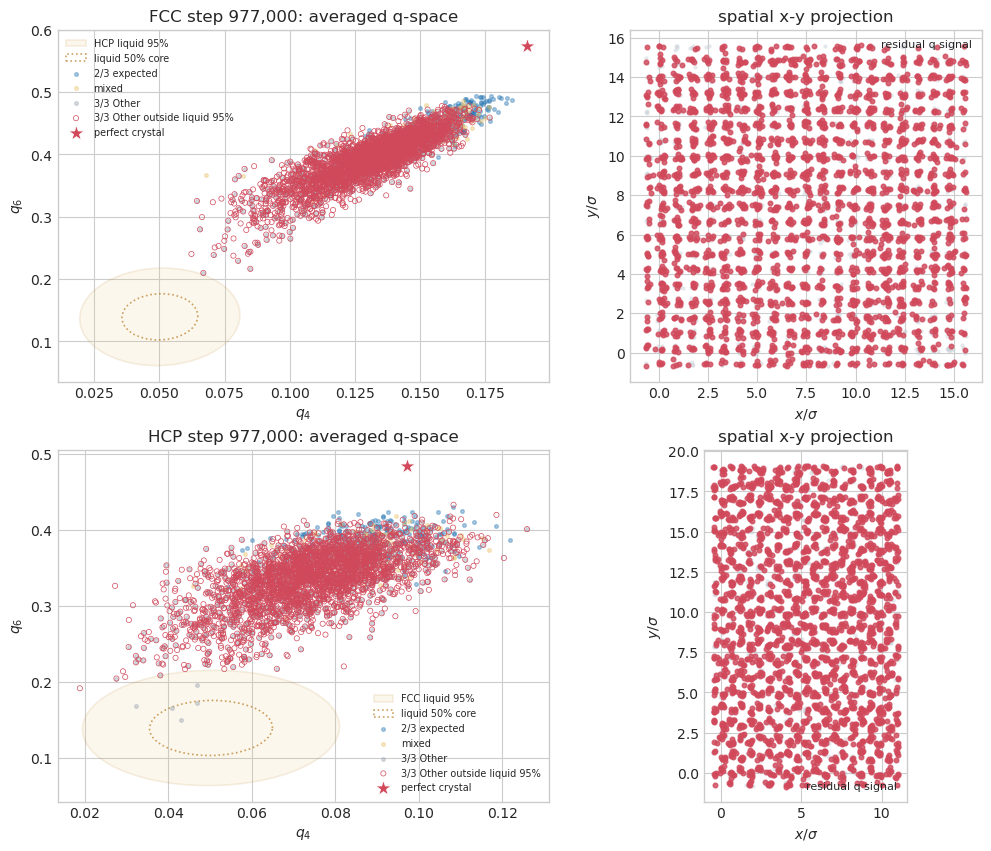

In [75]:
INSPECTION_STEPS = {}  # Example: {"fcc": 985000, "hcp": 977000}
averaged_q = failure_map[failure_map.feature_set.eq("averaged q")].copy()
inspection_rows = []
for run in RUNS:
    candidates = averaged_q[averaged_q.run.eq(run) & averaged_q.core_unanimous_other.between(.50, .95, inclusive="left")
                            & averaged_q.auc_low.gt(.55)].sort_values("core_unanimous_other")
    if run in INSPECTION_STEPS:
        chosen_step = min(averaged_q.loc[averaged_q.run.eq(run), "timestep"], key=lambda x: abs(x - INSPECTION_STEPS[run]))
    elif not candidates.empty:
        chosen_step = int(candidates.iloc[-1].timestep)
    else:
        fallback = averaged_q[averaged_q.run.eq(run) & averaged_q.core_unanimous_other.lt(.95)]
        chosen_step = int(fallback.sort_values(["core_unanimous_other", "auc"]).iloc[-1].timestep)
    inspection_rows.append(averaged_q[averaged_q.run.eq(run) & averaged_q.timestep.eq(chosen_step)].iloc[0])
inspection_frames = pd.DataFrame(inspection_rows).reset_index(drop=True)

qcols = ["q4_lechner_dellago", "q6_lechner_dellago"]
inspection_metrics = []
fig, axes = plt.subplots(len(RUNS), 2, figsize=(10.5, 4.2 * len(RUNS)), constrained_layout=True)
axes = np.atleast_2d(axes)
state_colors = {"2/3 expected": "#2878b5", "mixed": "#e9c46a", "3/3 Other": "#9aa5b1"}
for row, run in enumerate(RUNS):
    step = int(inspection_frames.loc[inspection_frames.run.eq(run), "timestep"].iloc[0])
    opposite_run = next(other for other in RUNS if other != run)
    frame = particles[particles.run.eq(run) & particles.timestep.eq(step)].copy()
    reference = empirical_liquid[empirical_liquid.run.eq(opposite_run)]
    center = reference[qcols].mean().to_numpy(); covariance = np.cov(reference[qcols].to_numpy(), rowvar=False)
    inverse = np.linalg.pinv(covariance)
    reference_delta = reference[qcols].to_numpy() - center
    reference_d2 = np.einsum("ni,ij,nj->n", reference_delta, inverse, reference_delta)
    threshold95 = np.quantile(reference_d2, .95)
    delta = frame[qcols].to_numpy() - center
    frame["outside_liquid95"] = np.einsum("ni,ij,nj->n", delta, inverse, delta) > threshold95
    frame["consensus_state"] = np.select(
        [frame.core_expected_2_of_3, frame.core_unanimous_other],
        ["2/3 expected", "3/3 Other"], default="mixed"
    )
    frame["residual_q_signal"] = frame.core_unanimous_other & frame.outside_liquid95
    inspection_metrics.append({"run": run, "timestep": step,
                               "fraction_3_of_3_other": frame.core_unanimous_other.mean(),
                               "fraction_residual_q_signal": frame.residual_q_signal.mean()})

    qax, spatial_ax = axes[row]
    add_distribution_ellipse(qax, reference[qcols[0]], reference[qcols[1]], .95,
                             facecolor="#e9c46a", edgecolor="#b7791f", alpha=.12, label=f"{opposite_run.upper()} liquid 95%")
    add_distribution_ellipse(qax, reference[qcols[0]], reference[qcols[1]], .50,
                             facecolor="none", edgecolor="#b7791f", alpha=.7, linestyle=":", label="liquid 50% core")
    plot_sample = frame.sample(n=min(1600, len(frame)), random_state=40 + row)
    for state in state_colors:
        part = plot_sample[plot_sample.consensus_state.eq(state)]
        qax.scatter(part[qcols[0]], part[qcols[1]], s=7, alpha=.38, color=state_colors[state], label=state)
    residual = frame[frame.residual_q_signal]
    qax.scatter(residual[qcols[0]], residual[qcols[1]], s=14, facecolor="none", edgecolor="#d1495b", lw=.5, label="3/3 Other outside liquid 95%")
    perfect = perfect_reference.loc[run]
    qax.scatter(perfect[qcols[0]], perfect[qcols[1]], marker="*", s=140, color="#d1495b", edgecolor="white", lw=.6, label="perfect crystal")
    qax.set(title=f"{run.upper()} step {step:,}: averaged q-space", xlabel=r"$q_4$", ylabel=r"$q_6$")
    qax.legend(frameon=False, fontsize=7, loc="best")

    spatial_ax.scatter(frame.x, frame.y, s=5, color="#c8d0d8", alpha=.35, rasterized=True)
    spatial_ax.scatter(residual.x, residual.y, s=11, color="#d1495b", alpha=.8, label="residual q signal", rasterized=True)
    spatial_ax.set(title="spatial x-y projection", xlabel=r"$x/\sigma$", ylabel=r"$y/\sigma$", aspect="equal")
    spatial_ax.legend(frameon=False, fontsize=8)
display(inspection_frames[["run", "timestep", "core_unanimous_other", "auc", "auc_low", "auc_high"]].round(3))
display(pd.DataFrame(inspection_metrics).round(3))
plt.show()


## Reading the result

- `Other / liquid-like` means unclassified by a crystal template, not a perfect liquid label.
- A falling 2-of-3 expected-crystal majority says the primary geometric rules no longer support the original lattice locally; it does not prove the true liquid fraction.
- Overlap with the amber empirical-liquid distribution is the physically relevant comparison; the gray ideal gas remains a limiting reference, not a phase boundary.
- Fixed-cutoff CNA is scale-sensitive and is not part of the primary consensus. If it diverges while adaptive/interval CNA and PTM agree, inspect density or nearest-neighbor distance first.
- C2ST AUC answers whether q-space differs from an independent liquid reference. It does **not** by itself answer whether the residual signal uniquely identifies FCC versus HCP.
- The revised HCP trajectory now shows the same late $Q_6$ collapse and mobility increase as FCC, so both runs can contribute independent empirical liquid references.

A natural next experiment is several seeds and heating/decompression rates per starting crystal, followed by aggregation of these sparse per-run summaries.